# Run five solvers on 20 versions of the (s, S) inventory problem.

Produces plots appearing in the INFORMS Journal on Computing submission.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the
parent simopt directory to the system path to import the necessary modules
later on.

In [1]:
import sys
from pathlib import Path

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

from simopt.experiment_base import (
    PlotType,
    plot_area_scatterplots,
    plot_progress_curves,
    plot_solvability_profiles,
    plot_terminal_progress,
    plot_terminal_scatterplots,
)
from simopt.experimental import run_experiment

## Experiment Configuration Parameters

Define the options used in the experiments.

In [2]:
# Experiment Configuration
num_macroreps = 10
num_postreps = 100
num_postnorms = 200

## Problem/Solver Configuration Parameters

Define the problems and solvers used in the experiments.

In [3]:
# Solvers to use in the experiment.
# Includes two versions of random search with varying sample sizes.
# The rename will be used in the plots to differentiate them.
solvers = [
    {"name": "BAYESOPT"},
   # {"name": "ASTRODF"},
    #{"name": "ADAM"},
    
]

In [4]:
# Configure the problem
demand_means = [25.0]
lead_means = [1.0]

# Create all the problem variants.
SSCONT_problems = [
    {
        "name": "SSCONT-1",
       # "rename": f"SSCONT-1_dm={dm}_lm={lm}",
       # "fixed_factors": {"budget": 1000},
        #"model_fixed_factors": {
        #    "demand_mean": dm,
         #  "lead_mean": lm,
        },
    
    #for dm in demand_means
   #for lm in lead_means
]

# Run the experiment for SSCONT problems.
SSCONT_experiments = run_experiment(
    problems=SSCONT_problems,
    solvers=solvers,
    num_macroreps=num_macroreps,
    num_postreps=num_postreps,
    num_postnorms=num_postnorms,
)

Running Problem 1/1: SSCONT-1...(600, 600)
(np.float64(0.26228312509015433), np.float64(8.162248853535335))
(np.float64(0.2138822373206507), np.float64(8.088149058710552))
(np.float64(0.17283990884914555), np.float64(8.125078750312417))
(600, 600)
(np.float64(0.13570223195153852), np.float64(8.094834332290464))
(np.float64(7.3508628245860965), np.float64(7.8543237209551355))
(600, 600)
(np.float64(0.33619788939346584), np.float64(8.306607931799824))
(600, 600)
(600, 600)
(np.float64(4.522093758125674), np.float64(8.205947977685643))
(np.float64(7.457183331971553), np.float64(7.7687700339369865))
(np.float64(0.23235147081527532), np.float64(7.9859251601324495))
(np.float64(1.1978457423746387), np.float64(0.81191144391838))
(np.float64(0.9247984230420719), np.float64(1.8228716052037883))
(np.float64(4.495875149765524), np.float64(8.21353378901608))
(600, 600)
(600, 600)
(np.float64(0.15138900174966835), np.float64(7.668117281274962))
(600, 600)
(np.float64(7.336795939145041), np.float64(

Done.
All experiments completed.


In [5]:
# Combine the experiments into a list of lists, where the outer list
# contains all the experiments for a single solver, and the inner lists
# contain the ProblemSolver instances associated with that solver.

experiment_dict = {}
for exp_problem_list in SSCONT_experiments:
    for experiment in exp_problem_list:
        # Use the solver name as the key and append the ProblemSolver instance.
        key = experiment.solver.name
        if key not in experiment_dict:
            experiment_dict[key] = []
        experiment_dict[key].append(experiment)
# Turn the dictionary into a list of lists.
experiments = list(experiment_dict.values())

## Plotting Settings

Define the plotting settings for the experiments.

In [6]:
enable_confidence_intervals = True
alpha = 0.2

/Users/rashijain/Desktop/simopt/simopt/bootstrap.py:516: RuntimeWarning: invalid value encountered in scalar divide
  (est_objective - bs_optimal_obj_val) / bs_initial_opt_gap


[PosixPath('/Users/rashijain/Desktop/simopt/notebooks/Continous_tests/experiments/2026-07-29_01-14-24/plots/SOLVER_SET_PROBLEM_SET_area_scatterplot.png')]

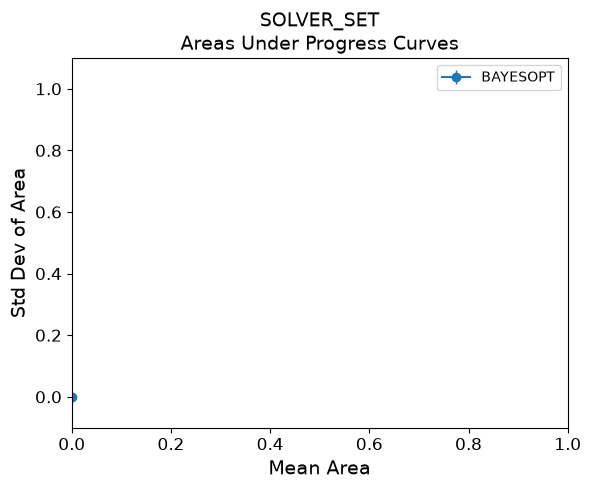

In [7]:
plot_area_scatterplots(
    experiments, all_in_one=True, plot_conf_ints=True, print_max_hw=True
)

[PosixPath('/Users/rashijain/Desktop/simopt/notebooks/Continous_tests/experiments/2026-07-29_01-14-24/plots/SOLVER_SET_PROBLEM_SET_profile_cdf_0.1_solve_times.png')]

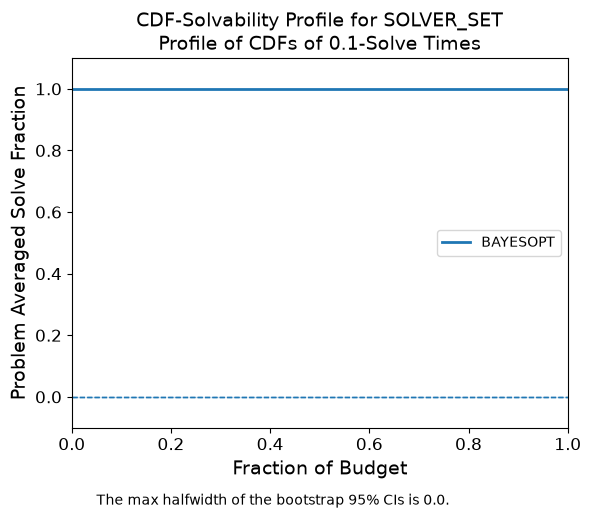

In [8]:
plot_solvability_profiles(
    experiments,
    plot_type=PlotType.CDF_SOLVABILITY,
    solve_tol=0.1,
    all_in_one=True,
    plot_conf_ints=True,
    print_max_hw=True,
)

[PosixPath('/Users/rashijain/Desktop/simopt/notebooks/Continous_tests/experiments/2026-07-29_01-14-24/plots/SOLVER_SET_PROBLEM_SET_profile_0.5_quantile_0.1_solve_times.png')]

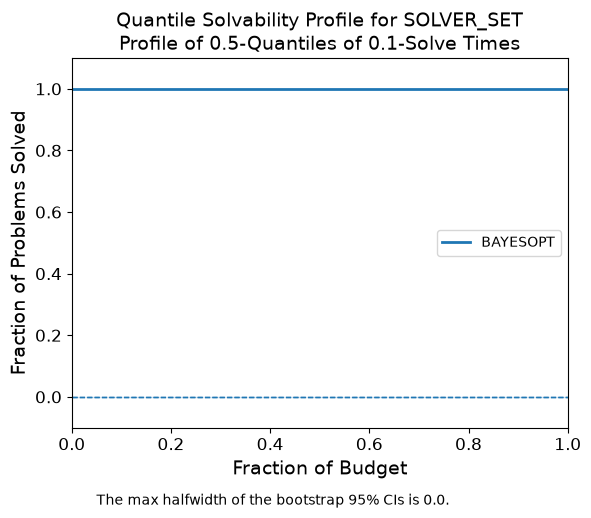

In [9]:
plot_solvability_profiles(
    experiments,
    plot_type=PlotType.QUANTILE_SOLVABILITY,
    solve_tol=0.1,
    beta=0.5,
    all_in_one=True,
    plot_conf_ints=True,
    print_max_hw=True,
)

ValueError: 'ASTRODF' is not in list

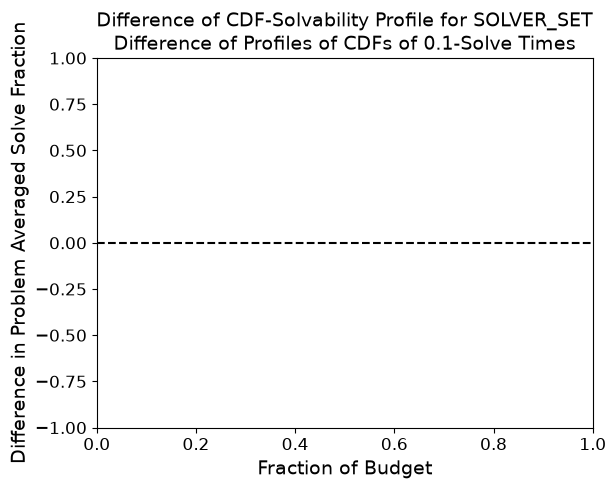

In [10]:
plot_solvability_profiles(
    experiments=experiments,
    plot_type=PlotType.DIFFERENCE_OF_CDF_SOLVABILITY,
    solve_tol=0.1,
    ref_solver="ASTRODF",
    all_in_one=True,
    plot_conf_ints=True,
    print_max_hw=True,
)

In [ ]:
plot_solvability_profiles(
    experiments=experiments,
    plot_type=PlotType.DIFFERENCE_OF_QUANTILE_SOLVABILITY,
    solve_tol=0.1,
    beta=0.5,
    ref_solver="ASTRODF",
    all_in_one=True,
    plot_conf_ints=True,
    print_max_hw=True,
)

In [ ]:
plot_terminal_scatterplots(experiments, all_in_one=True)

In [ ]:
n_problems = len(SSCONT_problems)
n_solvers = len(experiments)

for i in range(n_problems):
    plot_progress_curves(
        [experiments[solver_idx][i] for solver_idx in range(n_solvers)],
        plot_type=PlotType.MEAN,
        all_in_one=True,
        plot_conf_ints=True,
        print_max_hw=True,
        normalize=False,
    )
    plot_terminal_progress(
        [experiments[solver_idx][i] for solver_idx in range(n_solvers)],
        plot_type=PlotType.VIOLIN,
        normalize=True,
        all_in_one=True,
    )